# Visualise the values spread for some descriptors

In [2]:
from __future__ import annotations

import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rotadel.common.config import SQL_PATH
from rotadel.common.constants import (
    NUMBER_OF_CHI_ANGLES,
    ONE_TO_THREE_AA,
    THREE_TO_ONE_AA,
)
from rotadel.common.sql import get_descriptors

In [3]:
FIG_PATH = Path("figures").resolve()
print(f"Path to save plots: {FIG_PATH}")

Path to save plots: /cluster/project/jorner/lajacot/projects/rotadel/visualisation/distributions/figures


## Load data

In [4]:
RESIDUE = {"key": "PHE", "label": "Phenylalanine"}
DESCRIPTOR = {"key": "sterimol_l", "label": "Sterimol L"}


def validate_residue(selection: str) -> tuple[str, int]:
    normalized = selection.strip().upper()
    if normalized in ONE_TO_THREE_AA:
        letter = normalized
        residue = ONE_TO_THREE_AA[letter]
    elif normalized in THREE_TO_ONE_AA:
        residue = normalized
        letter = THREE_TO_ONE_AA[residue]
    else:
        raise ValueError(f"Unknown amino acid: {selection!r}.")

    number_of_chis = NUMBER_OF_CHI_ANGLES[letter]
    if number_of_chis < 2:
        raise ValueError(
            f"{residue} has {number_of_chis} χ angle(s); at least two are required."
        )
    if number_of_chis > 2:
        print(
            f"Note: {residue} has {number_of_chis} χ angles; plotting only χ1 and χ2."
        )
    return residue, number_of_chis


def load_residue_descriptors(
    path: Path, residue: str
) -> tuple[pd.DataFrame, list[str]]:
    with sqlite3.connect(f"file:{path}?mode=ro", uri=True) as connection:
        chis = pd.read_sql_query(
            "SELECT rotamer_id, chi1, chi2, prob FROM rotamers_data "
            "WHERE res = ? ORDER BY rowid",
            connection,
            params=(residue,),
            index_col="rotamer_id",
        )
    descriptors = get_descriptors(res=residue, sql_path=path).drop(
        columns=["residue", "charge", "tautomer"]
    )
    ensemble = chis.join(descriptors, validate="one_to_one")
    mol_descriptors = [
        name
        for name in descriptors.select_dtypes(include=np.number)
        if name != "charge_tot"
    ]
    if ensemble.empty:
        raise ValueError(f"No rotamers were found for {residue}.")
    return ensemble, mol_descriptors


residue, number_of_chis = validate_residue(RESIDUE["key"])
ensemble, mol_descriptors = load_residue_descriptors(SQL_PATH, residue)
if DESCRIPTOR["key"] not in ensemble:
    raise ValueError(
        f"Unknown descriptor {DESCRIPTOR['key']!r}. "
        f"Available names: {sorted(ensemble.columns[3:])}"
    )
if DESCRIPTOR["key"] not in mol_descriptors:
    raise TypeError(
        f"{DESCRIPTOR['key']!r} is not a continuous scalar. "
        f"Choose one of: {mol_descriptors}"
    )
if not np.isfinite(ensemble[["chi1", "chi2", "prob", *mol_descriptors]]).all().all():
    raise ValueError(f"The {residue} ensemble contains missing or non-finite values.")

print(
    f"Loaded {len(ensemble):,} {RESIDUE['label']} rotamers "
    f"({number_of_chis} χ angles)."
)

Loaded 23,318 Phenylalanine rotamers (2 χ angles).


## Plot descriptor distribution according to $\chi$

Plot complete rotamer ensemble for one amino acid in χ1/χ2 space, coloured by value of one selected descriptor

- Rotamers plotted on $(\chi_1, \chi_2)$ grid
- Problem: multiple rotamers less than 1° appart => overlap as if they were single point. Solution: one marker per occupied 1°×1° $\chi$ bin
- Marker size: according to log scale of rotamers count in that bin
    - Rescaling (to stay readable) of marker area from min 6 to max 60: $A(c) = 6 + (60-6){{log(c)}\over{log(1036)}}$ (1036 is larger rotamers count)
- Marker colour: mean value of selected descriptor in that bin

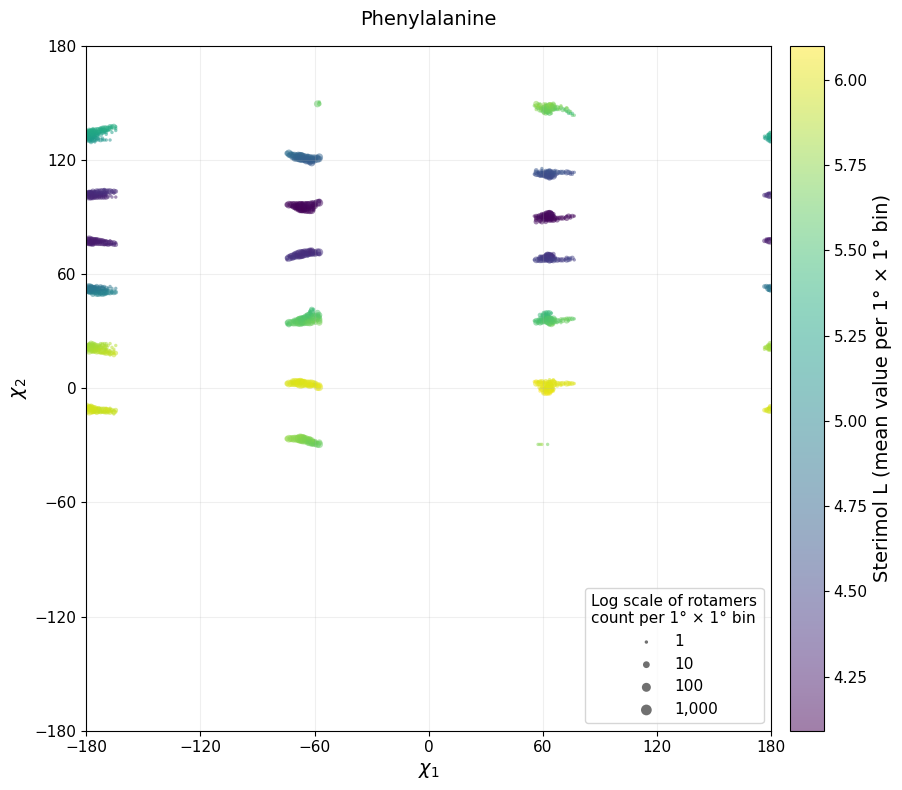

In [ ]:
BIN_WIDTH = 1
MIN_MARKER_AREA = 6
MAX_MARKER_AREA = 60
TICK_LABEL_SIZE = 11

binned = ensemble.assign(
    chi1_bin=np.floor(ensemble["chi1"] / BIN_WIDTH).clip(-180, 179) + 0.5,
    chi2_bin=np.floor(ensemble["chi2"] / BIN_WIDTH).clip(-180, 179) + 0.5,
)
summary = (
    binned.groupby(["chi1_bin", "chi2_bin"])[DESCRIPTOR["key"]]
    .agg(descriptor_mean="mean", rotamer_count="size")
    .reset_index()
)

maximum_count = summary["rotamer_count"].max()
log_maximum = max(np.log(maximum_count), 1)
summary["marker_area"] = (
    MIN_MARKER_AREA
    + (MAX_MARKER_AREA - MIN_MARKER_AREA)
    * np.log(summary["rotamer_count"])
    / log_maximum
)

fig, ax = plt.subplots(figsize=(10, 8))
points = ax.scatter(
    summary["chi1_bin"],
    summary["chi2_bin"],
    c=summary["descriptor_mean"],
    s=summary["marker_area"],
    alpha=0.5,
    cmap="viridis",
    edgecolors="none",
    rasterized=True,
)
ticks = np.arange(-180, 181, 60)
ax.set(
    xlim=(-180, 180),
    ylim=(-180, 180),
    xticks=ticks,
    yticks=ticks,
    aspect="equal",
)
ax.set_title(f"{RESIDUE['label']}", fontsize=14, pad=15)
ax.set_xlabel(r"$\chi_1$", fontsize=14)
ax.set_ylabel(r"$\chi_2$", fontsize=14)
ax.tick_params(labelsize=TICK_LABEL_SIZE)
ax.grid(alpha=0.2)

colorbar = fig.colorbar(points, ax=ax, pad=0.02)
colorbar.set_label(f"{DESCRIPTOR['label']} (mean value per 1° × 1° bin)", fontsize=14)
colorbar.ax.tick_params(labelsize=TICK_LABEL_SIZE)

legend_counts = np.array([1, 10, 100, 1000])
legend_counts = legend_counts[legend_counts <= maximum_count]
legend_areas = MIN_MARKER_AREA + (MAX_MARKER_AREA - MIN_MARKER_AREA) * (
    np.log(legend_counts) / log_maximum
)
handles = [
    ax.scatter([], [], s=area, color="0.25", alpha=0.75, edgecolors="none")
    for area in legend_areas
]
ax.legend(
    handles,
    [f"{count:,}" for count in legend_counts],
    title="Log scale of rotamers\ncount per 1° × 1° bin",
    loc="lower right",
    fontsize=11,
    title_fontsize=11,
)
fig.tight_layout()

# Uncomment to save figure
# fig.savefig(FIG_PATH / "sidechain_angles.png", dpi=600, bbox_inches="tight")

## Descriptors kernel density

Plot the joint kernel densities of one steric and one electronic descriptor, for four selected amino acids with 4-3-2-1 $\chi$ angles:
- descriptors: Sterimol L and $P_{int}$
- AA: LYS, GLU, PHE, and CYS

In [25]:
from matplotlib.colors import to_rgb
from scipy.stats import gaussian_kde

### Load data

In [ ]:
KDE_DESCRIPTORS = ["p_int", "sterimol_l"]
comparison_residues = ["LYS", "GLU", "PHE", "CYS"]

comparison_ensembles = {
    residue: get_descriptors(res=residue, sql_path=SQL_PATH)[KDE_DESCRIPTORS]
    for residue in comparison_residues
}
for residue, values in comparison_ensembles.items():
    number_of_chis = NUMBER_OF_CHI_ANGLES[THREE_TO_ONE_AA[residue]]
    print(f"Loaded {len(values)} {residue} rotamers ({number_of_chis} χ).")

Loaded 189,216 LYS rotamers (4 χ).
Loaded 139,964 GLU rotamers (3 χ).
Loaded 23,318 PHE rotamers (2 χ).
Loaded 7,776 CYS rotamers (1 χ).


### Run KDE

In [27]:
KDE_MAX_POINTS = 15_000
KDE_GRID_SIZE = 120
KDE_LEVELS = (0.02, 0.10, 0.30, 0.60)

comparison_values = {}
for index, (residue, frame) in enumerate(comparison_ensembles.items()):
    values = frame.to_numpy()
    if len(values) > KDE_MAX_POINTS:
        rng = np.random.default_rng(2026 + index)
        values = values[rng.choice(len(values), KDE_MAX_POINTS, replace=False)]
    comparison_values[residue] = values

comparison_kdes = {
    residue: gaussian_kde(values.T) for residue, values in comparison_values.items()
}
pooled = np.vstack([frame.to_numpy() for frame in comparison_ensembles.values()])
data_min, data_max = pooled.min(axis=0), pooled.max(axis=0)
padding = np.ptp(pooled, axis=0) * (0.05, 0.1125)
limits = np.column_stack((data_min - padding, data_max + padding))
x_grid, y_grid = (np.linspace(*axis_limits, KDE_GRID_SIZE) for axis_limits in limits)
xx, yy = np.meshgrid(x_grid, y_grid)
positions = np.vstack([xx.ravel(), yy.ravel()])
comparison_densities = {
    residue: kde(positions).reshape(xx.shape)
    for residue, kde in comparison_kdes.items()
}

comparison_marginals = {}
for residue, values in comparison_values.items():
    marginal_x = gaussian_kde(values[:, 0])(x_grid)
    marginal_y = gaussian_kde(values[:, 1])(y_grid)
    # Normalise KDE intensities to each amino acid’s maximum
    comparison_marginals[residue] = (
        marginal_x / marginal_x.max(),
        marginal_y / marginal_y.max(),
    )

### Plot

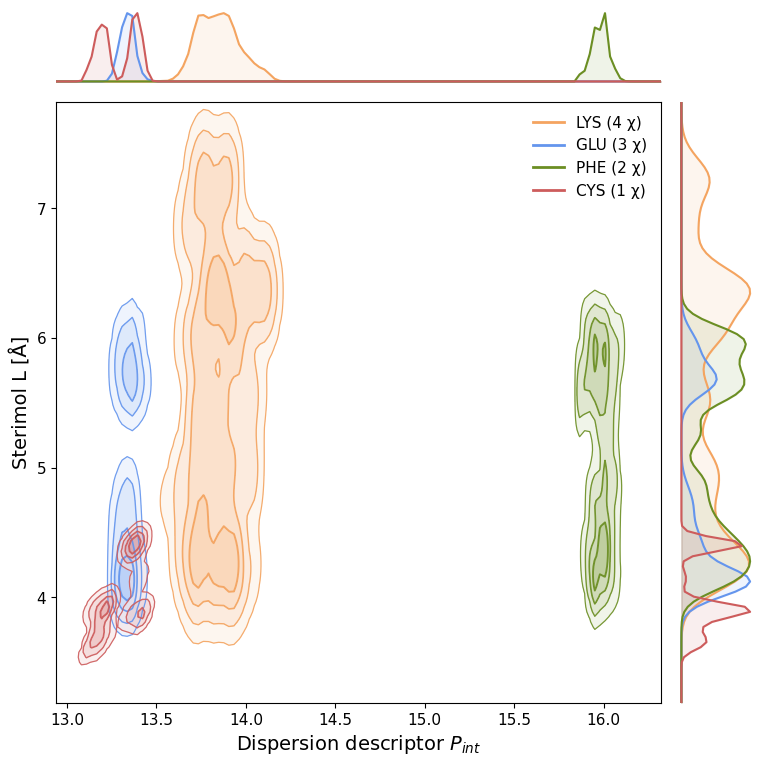

In [29]:
COMPARISON_COLORS = {
    "LYS": "sandybrown",
    "GLU": "cornflowerblue",
    "PHE": "olivedrab",
    "CYS": "indianred",
}
FILL_LIGHTNESS = (0.82, 0.62, 0.42, 0.22)

fig = plt.figure(figsize=(9, 9))
grid = fig.add_gridspec(
    2, 2, width_ratios=(8, 1), height_ratios=(1, 8), hspace=0.05, wspace=0.05
)
ax_marginal_x = fig.add_subplot(grid[0, 0])
ax = fig.add_subplot(grid[1, 0], sharex=ax_marginal_x)
ax_marginal_y = fig.add_subplot(grid[1, 1], sharey=ax)

for residue in comparison_residues:
    color = COMPARISON_COLORS[residue]
    base_color = np.asarray(to_rgb(color))
    fill_colors = [tuple((1 - value) * base_color + value) for value in FILL_LIGHTNESS]
    # Normalize KDE height only; xx and yy retain the descriptor values.
    density = comparison_densities[residue] / comparison_densities[residue].max()
    ax.contourf(
        xx, yy, density, levels=(*KDE_LEVELS, 1.0), colors=fill_colors, alpha=0.55
    )
    ax.contour(
        xx,
        yy,
        density,
        levels=KDE_LEVELS,
        colors=[color],
        linewidths=(0.9, 1.0, 1.2, 1.4),
        alpha=0.9,
    )
    ax.plot(
        [],
        [],
        color=color,
        linewidth=2,
        label=f"{residue} ({NUMBER_OF_CHI_ANGLES[THREE_TO_ONE_AA[residue]]} χ)",
    )

    marginal_x, marginal_y = comparison_marginals[residue]
    ax_marginal_x.plot(x_grid, marginal_x, color=color, linewidth=1.5)
    ax_marginal_x.fill_between(x_grid, marginal_x, color=color, alpha=0.10)
    ax_marginal_y.plot(marginal_y, y_grid, color=color, linewidth=1.5)
    ax_marginal_y.fill_betweenx(y_grid, marginal_y, color=color, alpha=0.10)

ax.legend(frameon=False, fontsize=11)
ax.set(xlim=limits[0], ylim=limits[1])
ax.set_xlabel(r"Dispersion descriptor $P_{int}$", fontsize=14)
ax.set_ylabel("Sterimol L [Å]", fontsize=14)
ax.tick_params(labelsize=TICK_LABEL_SIZE)

for current_ax in (ax, ax_marginal_x, ax_marginal_y):
    current_ax.set_facecolor("white")
    current_ax.grid(False)
for marginal_ax in (ax_marginal_x, ax_marginal_y):
    marginal_ax.tick_params(
        left=False, bottom=False, labelleft=False, labelbottom=False
    )
    for spine in marginal_ax.spines.values():
        spine.set_visible(False)

# Uncomment to save figure
fig.savefig(FIG_PATH / "kernel_densities.png", dpi=600, bbox_inches="tight")